## 1. Imports

In [1]:
!pip install -q \
transformers==4.40.2 \
accelerate==0.29.3 \
datasets==2.19.2

In [2]:
import os

if not os.path.exists("/content/IRONHACK-AI-PROJECT3"):
    !git clone https://github.com/Martigol2/IRONHACK-AI-PROJECT3.git

%cd /content/IRONHACK-AI-PROJECT3/Classification

fatal: destination path 'IRONHACK-AI-PROJECT3' already exists and is not an empty directory.
/content/IRONHACK-AI-PROJECT3/Classification
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

print("✅ Transformers imported successfully")

✅ Transformers imported successfully


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from datasets import Dataset

from functions import (
    load_splits,
    evaluate,
    compute_metrics,
    LABELS,
    RANDOM_STATE,
)

## 2. Load data the canonical split

In [11]:
DATA_PATH = "/content/drive/MyDrive/IRONHACK-AI-PROJECT3 / data/processed/amazon_reviews_clean.csv"

X_train, X_val, X_test, y_train, y_val, y_test = load_splits(DATA_PATH)

scores = []

print(len(X_train), len(X_val), len(X_test))

24238 5194 5194


## 3. Label encoding

In [12]:
label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2,
}

id2label = {v: k for k, v in label2id.items()}

y_train = y_train.map(label2id)
y_val = y_val.map(label2id)
y_test = y_test.map(label2id)

In [13]:
print(y_train.value_counts().sort_index())

sentiment
0      569
1     1049
2    22620
Name: count, dtype: int64


## 4. Tokenization
###   4.1 Load tokenizer

In [14]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

###   4.2 Review length analysis

In [15]:
sample = X_train.iloc[0]

print(sample)

Amazon fire 7 tablet. This is a good tablet, next time I buy a tablet I will get a bigger one. It does all we need it to. Great for kids!


In [16]:
encoding = tokenizer(sample)

encoding.keys()

dict_keys(['input_ids', 'attention_mask'])

In [17]:
print(encoding["input_ids"][:20])

[101, 9733, 2543, 1021, 13855, 1012, 2023, 2003, 1037, 2204, 13855, 1010, 2279, 2051, 1045, 4965, 1037, 13855, 1045, 2097]


In [18]:
review_lengths = X_train.str.split().str.len()

review_lengths.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99])

,text_full
count,24238.000000
mean,33.819952
std,34.611427
min,2.000000
50%,24.000000
75%,39.000000
90%,63.000000
95%,84.000000
99%,160.630000
max,1868.000000


###  4.3 Maximum sequence length

The review length distribution was analysed before tokenization. Since 95% of the reviews contain fewer than 84 words (99% fewer than 161 words), a maximum sequence length of 128 tokens was selected. This provides a good balance between computational efficiency and information retention while reducing memory usage and training time.

In [19]:
# 4.3 Maximum sequence length
MAX_LENGTH = 128

In [20]:
# 4.4 Create Hugging Face datasets
train_ds = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_ds = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [21]:
# 4.5 Tokenization
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

###    4.4 Create Hugging Face datasets

In [22]:
train_ds = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_ds = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [23]:
train_ds[0]

{'text': 'Amazon fire 7 tablet. This is a good tablet, next time I buy a tablet I will get a bigger one. It does all we need it to. Great for kids!',
 'label': 1}

###  4.5 Tokenize datasets

In [24]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [25]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/24238 [00:00<?, ? examples/s]

Map:   0%|          | 0/5194 [00:00<?, ? examples/s]

Map:   0%|          | 0/5194 [00:00<?, ? examples/s]

###     4.6 Convert to PyTorch

In [26]:
train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

###   4.7 Verify tokenization

In [27]:
sample = train_ds[0]

print(sample.keys())

dict_keys(['label', 'input_ids', 'attention_mask'])


In [28]:
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)

torch.Size([128])
torch.Size([128])


## 5. Build DistilBERT model

In [29]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 6. Fine-tuning

### 6.1 Training hyperparameters

The following hyperparameters were selected as a standard starting point for fine-tuning DistilBERT on the sentiment classification task.

| Parameter | Value | Reason |
|------------|:-----:|--------|
| Number of epochs | **3** | Standard starting point for fine-tuning BERT-based models. |
| Learning rate | **2e-5** | One of the recommended learning rates in the original BERT paper; allows stable fine-tuning without large weight updates. |
| Batch size | **16** | Provides a good balance between training speed, memory usage, and model stability. |
| Weight decay | **0.01** | Helps reduce overfitting by applying L2 regularization during training. |
| Best model selection | **Validation loss** | Retains the checkpoint with the lowest validation loss rather than simply keeping the final epoch. |

In [30]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert",

    evaluation_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    logging_steps=100,

    fp16=True,              # <-- Add this
    seed=RANDOM_STATE,
)

### 6.2 Create the Trainer

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

### 6.3 Start training

In [32]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.176000,0.166071,0.952445,0.637799,0.943129
2,0.158900,0.152372,0.953023,0.681566,0.949535
3,0.104600,0.182190,0.951097,0.673846,0.946886


TrainOutput(global_step=4545, training_loss=0.14083160026894412, metrics={'train_runtime': 540.8755, 'train_samples_per_second': 134.438, 'train_steps_per_second': 8.403, 'total_flos': 2408101550774784.0, 'train_loss': 0.14083160026894412, 'epoch': 3.0})

## 7. Validation

In [35]:
val_results = trainer.evaluate(eval_dataset=val_ds)

print("Validation Results")
print(val_results)

Validation Results
{'eval_loss': 0.15237227082252502, 'eval_accuracy': 0.9530227185213708, 'eval_f1_macro': 0.6815664345389001, 'eval_f1_weighted': 0.9495347702123187, 'eval_runtime': 6.4712, 'eval_samples_per_second': 802.635, 'eval_steps_per_second': 50.223, 'epoch': 3.0}


## 8. Final evaluation on the test set

In [36]:
test_results = trainer.evaluate(eval_dataset=test_ds)

print("Test Results")
print(test_results)

Test Results
{'eval_loss': 0.16065779328346252, 'eval_accuracy': 0.9524451289949942, 'eval_f1_macro': 0.7042100143166063, 'eval_f1_weighted': 0.9497761756682074, 'eval_runtime': 6.8575, 'eval_samples_per_second': 757.417, 'eval_steps_per_second': 47.393, 'epoch': 3.0}


### 8.1 Predictions

In [37]:
predictions = trainer.predict(test_ds)

In [38]:
y_pred = predictions.predictions.argmax(axis=1)
y_true = np.array(y_test)

### 8.2 Classification Report

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS
    )
)

              precision    recall  f1-score   support

    Negative       0.80      0.61      0.69       122
     Neutral       0.49      0.41      0.44       225
    Positive       0.97      0.99      0.98      4847

    accuracy                           0.95      5194
   macro avg       0.75      0.67      0.70      5194
weighted avg       0.95      0.95      0.95      5194



DistilBERT achieved an overall accuracy of 95% on the test set. The model performed exceptionally well in identifying positive reviews (F1-score = 0.98), while performance was lower for the negative and neutral classes. This behavior is largely explained by the strong class imbalance in the dataset, where positive reviews account for the vast majority of observations. Future improvements could include applying class balancing techniques, weighted loss functions, or data augmentation to improve minority-class performance.

### 8.3 Confusion Matrix

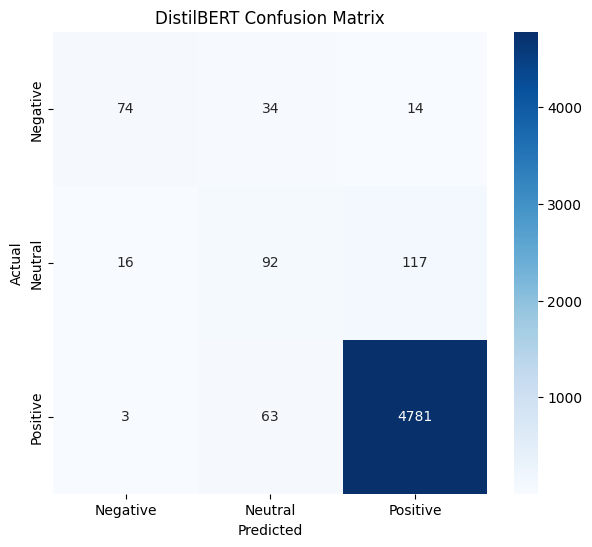

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

## 9. Comparison with the other models

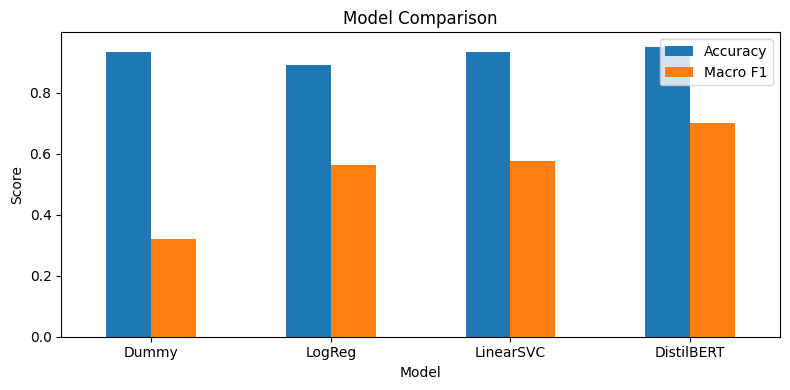

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Dummy",
        "LogReg",
        "LinearSVC",
        "DistilBERT"
    ],
    "Accuracy": [0.9334, 0.8903, 0.9324, 0.9500],
    "Macro F1": [0.3218, 0.5623, 0.5771, 0.7000]
})

comparison.set_index("Model")[["Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(8,4)
)

plt.ylabel("Score")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Save model

In [43]:
MODEL_PATH = "/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

('/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert/tokenizer_config.json',
 '/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert/special_tokens_map.json',
 '/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert/vocab.txt',
 '/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert/added_tokens.json',
 '/content/drive/MyDrive/IRONHACK-AI-PROJECT3/models/distilbert/tokenizer.json')